## Imports & Setup

In [1]:
import os
from pathlib import Path
import glob
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from imblearn.over_sampling import SMOTE

import shap

warnings.filterwarnings("ignore")

# Controls seed for models
SEED = 42
np.random.seed(SEED)

/home/phillip/IDS_Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_project_root():
    path = Path.cwd()

    while path != path.parent:
        if (path / "models").exists() and (path / "raw_data").exists():
            return path
        path = path.parent


# Detect base path automatically so it can work for anyone running the code.
if "__file__" in globals():
    BASE_PATH = get_project_root()
else:
    BASE_PATH = get_project_root()

# Paths
RAW_DATA_PATH = BASE_PATH / "raw_data" / "MachineLearningCVE"
RESULTS_PATH = BASE_PATH / "results"
MODELS_PATH = BASE_PATH / "models"
ARTIFACTS_PATH = BASE_PATH / "artifacts"

# Ensure folders exist
RESULTS_PATH.mkdir(exist_ok=True)
MODELS_PATH.mkdir(exist_ok=True)
ARTIFACTS_PATH.mkdir(exist_ok=True)

print("BASE_PATH:", BASE_PATH)

BASE_PATH: /home/phillip/IDS_Project


In [3]:
# Load and combine all CSV files
all_files = glob.glob(os.path.join(RAW_DATA_PATH, "*.csv"))
print(f"CSV files found: {len(all_files)}")

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print("Combined shape:", df.shape)
df.head()

CSV files found: 8
Combined shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# Preprocess data
df.columns = df.columns.str.strip()

# Remove duplicate column names
df = df.loc[:, ~df.columns.duplicated()]

# Replace inf with NaN, then drop rows with missing values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

before_dropna = df.shape[0]
df.dropna(inplace=True)
after_dropna = df.shape[0]

print("Rows removed due to NaN/inf:", before_dropna - after_dropna)

# Remove duplicates
before_dups = df.shape[0]
df.drop_duplicates(inplace=True)
after_dups = df.shape[0]

print("Duplicate rows removed:", before_dups - after_dups)
print("Cleaned shape:", df.shape)

# Done to reduce ram
for col in df.columns:
    if col not in ["Label"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

print("Converted numeric columns to float32")

Rows removed due to NaN/inf: 2867
Duplicate rows removed: 307078
Cleaned shape: (2520798, 79)
Converted numeric columns to float32


In [5]:
# Rename CIC-IDS2017 columns to CICFlowMeter output format so it works with wireshark pcaps.

TRAINING_TO_CICFLOWMETER_MAP = {
    # Basic flow
    "Destination Port": "dst_port",
    "Flow Duration": "flow_duration",

    # Packet counts
    "Total Fwd Packets": "tot_fwd_pkts",
    "Total Backward Packets": "tot_bwd_pkts",

    # Bytes
    "Total Length of Fwd Packets": "totlen_fwd_pkts",
    "Total Length of Bwd Packets": "totlen_bwd_pkts",

    # Forward packet stats
    "Fwd Packet Length Max": "fwd_pkt_len_max",
    "Fwd Packet Length Min": "fwd_pkt_len_min",
    "Fwd Packet Length Mean": "fwd_pkt_len_mean",
    "Fwd Packet Length Std": "fwd_pkt_len_std",

    # Backward packet stats
    "Bwd Packet Length Max": "bwd_pkt_len_max",
    "Bwd Packet Length Min": "bwd_pkt_len_min",
    "Bwd Packet Length Mean": "bwd_pkt_len_mean",
    "Bwd Packet Length Std": "bwd_pkt_len_std",

    # Rates
    "Flow Bytes/s": "flow_byts_s",
    "Flow Packets/s": "flow_pkts_s",
    "Fwd Packets/s": "fwd_pkts_s",
    "Bwd Packets/s": "bwd_pkts_s",

    # Packet length general
    "Min Packet Length": "pkt_len_min",
    "Max Packet Length": "pkt_len_max",
    "Packet Length Mean": "pkt_len_mean",
    "Packet Length Std": "pkt_len_std",
    "Packet Length Variance": "pkt_len_var",

    # IAT
    "Flow IAT Mean": "flow_iat_mean",
    "Flow IAT Std": "flow_iat_std",
    "Flow IAT Max": "flow_iat_max",
    "Flow IAT Min": "flow_iat_min",

    "Fwd IAT Total": "fwd_iat_tot",
    "Fwd IAT Mean": "fwd_iat_mean",
    "Fwd IAT Std": "fwd_iat_std",
    "Fwd IAT Max": "fwd_iat_max",
    "Fwd IAT Min": "fwd_iat_min",

    "Bwd IAT Total": "bwd_iat_tot",
    "Bwd IAT Mean": "bwd_iat_mean",
    "Bwd IAT Std": "bwd_iat_std",
    "Bwd IAT Max": "bwd_iat_max",
    "Bwd IAT Min": "bwd_iat_min",

    # Flags
    "Fwd PSH Flags": "fwd_psh_flags",
    "Bwd PSH Flags": "bwd_psh_flags",
    "Fwd URG Flags": "fwd_urg_flags",
    "Bwd URG Flags": "bwd_urg_flags",

    "FIN Flag Count": "fin_flag_cnt",
    "SYN Flag Count": "syn_flag_cnt",
    "RST Flag Count": "rst_flag_cnt",
    "PSH Flag Count": "psh_flag_cnt",
    "ACK Flag Count": "ack_flag_cnt",
    "URG Flag Count": "urg_flag_cnt",
    "CWE Flag Count": "cwr_flag_count",
    "ECE Flag Count": "ece_flag_cnt",

    # Header
    "Fwd Header Length": "fwd_header_len",
    "Bwd Header Length": "bwd_header_len",
    "Fwd Header Length.1": "fwd_header_len",

    # Ratios
    "Down/Up Ratio": "down_up_ratio",

    # Sizes
    "Average Packet Size": "pkt_size_avg",
    "Avg Fwd Segment Size": "fwd_seg_size_avg",
    "Avg Bwd Segment Size": "bwd_seg_size_avg",

    # Bulk features
    "Fwd Avg Bytes/Bulk": "fwd_byts_b_avg",
    "Fwd Avg Packets/Bulk": "fwd_pkts_b_avg",
    "Fwd Avg Bulk Rate": "fwd_blk_rate_avg",
    "Bwd Avg Bytes/Bulk": "bwd_byts_b_avg",
    "Bwd Avg Packets/Bulk": "bwd_pkts_b_avg",
    "Bwd Avg Bulk Rate": "bwd_blk_rate_avg",

    # Subflow
    "Subflow Fwd Packets": "subflow_fwd_pkts",
    "Subflow Fwd Bytes": "subflow_fwd_byts",
    "Subflow Bwd Packets": "subflow_bwd_pkts",
    "Subflow Bwd Bytes": "subflow_bwd_byts",

    # Windows
    "Init_Win_bytes_forward": "init_fwd_win_byts",
    "Init_Win_bytes_backward": "init_bwd_win_byts",

    # Misc
    "act_data_pkt_fwd": "fwd_act_data_pkts",
    "min_seg_size_forward": "fwd_seg_size_min",

    # Active/Idle
    "Active Mean": "active_mean",
    "Active Std": "active_std",
    "Active Max": "active_max",
    "Active Min": "active_min",

    "Idle Mean": "idle_mean",
    "Idle Std": "idle_std",
    "Idle Max": "idle_max",
    "Idle Min": "idle_min",
}

# Rename columns based on the mapping
df = df.rename(columns=TRAINING_TO_CICFLOWMETER_MAP)

# remove duplicates caused by "Fwd Header Length.1"
df = df.loc[:, ~df.columns.duplicated()]

In [6]:
# Analyze label distribution
print("Unique labels:")
print(df["Label"].value_counts())

label_counts = df["Label"].value_counts().reset_index()
label_counts.columns = ["Label", "Count"]
label_counts

Unique labels:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


,Label,Count
0,BENIGN,2095057
1,DoS Hulk,172846
2,DDoS,128014
3,PortScan,90694
4,DoS GoldenEye,10286
5,FTP-Patator,5931
6,DoS slowloris,5385
7,DoS Slowhttptest,5228
8,SSH-Patator,3219
9,Bot,1948


In [7]:
# Binary labeling: BENIGN = 0, ATTACK = 1
df_binary = df.copy()
df_binary["Binary_Label"] = df_binary["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

print("Binary label distribution:")
print(df_binary["Binary_Label"].value_counts())

Binary label distribution:
Binary_Label
0    2095057
1     425741
Name: count, dtype: int64


In [8]:
# Multi-class labeling to group similar attack types together
df_multi = df.copy()

# Print original multi-class distribution
print("Original multi-class labels:")
print(df_multi["Label"].value_counts())


def simplify_attack_label(label):
    if label == "BENIGN":
        return "BENIGN"
    elif "DoS" in label or "DDoS" in label:
        return "DoS/DDoS"
    elif "PortScan" in label:
        return "PortScan"
    elif "Bot" in label:
        return "Bot"
    elif "Brute Force" in label or "Patator" in label:
        return "BruteForce"
    elif "Web Attack" in label:
        return "WebAttack"
    elif "Infiltration" in label:
        return "Infiltration"
    elif "Heartbleed" in label:
        return "Heartbleed"
    else:
        return "OtherAttack"

df_multi["Attack_Category"] = df_multi["Label"].apply(simplify_attack_label)

print("Simplified multi-class distribution:")
print(df_multi["Attack_Category"].value_counts())

Original multi-class labels:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Simplified multi-class distribution:
Attack_Category
BENIGN          2095057
DoS/DDoS         321759
PortScan          90694
BruteForce        10620
Bot                1948
WebAttack           673
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


In [9]:
# Drop columns that should not be used as features
drop_cols = ["Label", "Binary_Label", "Attack_Category"]

binary_feature_cols = [c for c in df_binary.columns if c not in drop_cols]
multi_feature_cols = [c for c in df_multi.columns if c not in drop_cols]

X_binary = df_binary[binary_feature_cols].copy()
y_binary = df_binary["Binary_Label"].copy()

X_multi = df_multi[multi_feature_cols].copy()
y_multi = df_multi["Attack_Category"].copy()

print("Binary feature shape:", X_binary.shape)
print("Binary target shape:", y_binary.shape)
print("Multi feature shape:", X_multi.shape)
print("Multi target shape:", y_multi.shape)

Binary feature shape: (2520798, 77)
Binary target shape: (2520798,)
Multi feature shape: (2520798, 77)
Multi target shape: (2520798,)


In [10]:
# Split data into training and testing sets
# Random split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=SEED,
    stratify=y_binary
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=SEED,
    stratify=y_multi
)

# Check test labels
print("\nBinary test label distribution:")
print(y_test_bin.value_counts())

print("\nMulti-class test label distribution:")
print(y_test_multi.value_counts())


Binary test label distribution:
Binary_Label
0    419012
1     85148
Name: count, dtype: int64

Multi-class test label distribution:
Attack_Category
BENIGN          419012
DoS/DDoS         64352
PortScan         18139
BruteForce        2124
Bot                390
WebAttack          134
Infiltration         7
Heartbleed           2
Name: count, dtype: int64


In [11]:
# Smote

print("Before SMOTE:")
print(y_train_bin.value_counts())

smote = SMOTE(random_state=SEED)

X_train_bin_smote, y_train_bin_smote = smote.fit_resample(
    X_train_bin,
    y_train_bin
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_bin_smote).value_counts())

Before SMOTE:
Binary_Label
0    1676045
1     340593
Name: count, dtype: int64

After SMOTE:
Binary_Label
1    1676045
0    1676045
Name: count, dtype: int64


In [12]:
# Encode multi-class labels
multi_label_encoder = LabelEncoder()

y_train_multi_enc = multi_label_encoder.fit_transform(y_train_multi)
y_test_multi_enc = multi_label_encoder.transform(y_test_multi)

print("Multi-class label mapping:")
for idx, cls in enumerate(multi_label_encoder.classes_):
    print(f"{idx}: {cls}")

Multi-class label mapping:
0: BENIGN
1: Bot
2: BruteForce
3: DoS/DDoS
4: Heartbleed
5: Infiltration
6: PortScan
7: WebAttack


In [13]:
# Save feature metadata
binary_feature_names = X_train_bin.columns.tolist()
multi_feature_names = X_train_multi.columns.tolist()

print("Number of binary features:", len(binary_feature_names))
print("Number of multi-class features:", len(multi_feature_names))

joblib.dump(binary_feature_names, os.path.join(ARTIFACTS_PATH, "binary_feature_names.pkl"))
joblib.dump(multi_feature_names, os.path.join(ARTIFACTS_PATH, "multi_feature_names.pkl"))
joblib.dump(multi_label_encoder, os.path.join(ARTIFACTS_PATH, "multi_label_encoder.pkl"))

print("Saved feature metadata.")

Number of binary features: 77
Number of multi-class features: 77
Saved feature metadata.


## Functions

In [14]:
# Helper Functions for Evaluation

def evaluate_binary_model(model, X_train, X_test, y_train, y_test, model_name, scaler=None):
    """
    Train and evaluate a binary classification model.
    Returns:
        metrics_dict, y_pred, y_prob, training_time
    """
    X_train_used = X_train.copy()
    X_test_used = X_test.copy()

    if scaler is not None:
        X_train_used = scaler.fit_transform(X_train_used)
        X_test_used = scaler.transform(X_test_used)

    start_time = time.time()
    model.fit(X_train_used, y_train)
    end_time = time.time()

    training_time = end_time - start_time

    y_pred = model.predict(X_test_used)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_used)[:, 1]
    else:
        y_prob = None

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "Training Time": training_time,
    }

    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_prob)
        metrics["PR-AUC"] = average_precision_score(y_test, y_prob)
    else:
        metrics["ROC-AUC"] = np.nan
        metrics["PR-AUC"] = np.nan

    return metrics, y_pred, y_prob, training_time

In [15]:
# Plot helper functions for confusion matrix, ROC curve, and PR curve

def plot_binary_confusion_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "ATTACK"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.show()


def plot_roc(y_true, y_prob, title):
    if y_prob is None:
        print(f"ROC curve skipped for {title} because predict_proba is unavailable.")
        return

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_pr(y_true, y_prob, title):
    if y_prob is None:
        print(f"PR curve skipped for {title} because predict_proba is unavailable.")
        return

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Logistic Regression

In [16]:
# Logistic Regression

log_scaler = StandardScaler()

log_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

log_metrics, y_pred_log, y_prob_log, log_train_time = evaluate_binary_model(
    model=log_model,
    X_train=X_train_bin,
    X_test=X_test_bin,
    y_train=y_train_bin,
    y_test=y_test_bin,
    model_name="Logistic Regression",
    scaler=log_scaler
)

print("Logistic Regression Results:")
for k, v in log_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_log, target_names=["BENIGN", "ATTACK"]))

Logistic Regression Results:
Model: Logistic Regression
Accuracy: 0.9571
Precision: 0.8819
Recall: 0.8612
F1-Score: 0.8714
Training Time: 125.3853
ROC-AUC: 0.9880
PR-AUC: 0.9507

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.97      0.98      0.97    419012
      ATTACK       0.88      0.86      0.87     85148

    accuracy                           0.96    504160
   macro avg       0.93      0.92      0.92    504160
weighted avg       0.96      0.96      0.96    504160



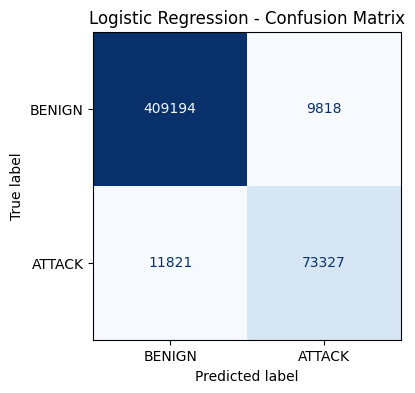

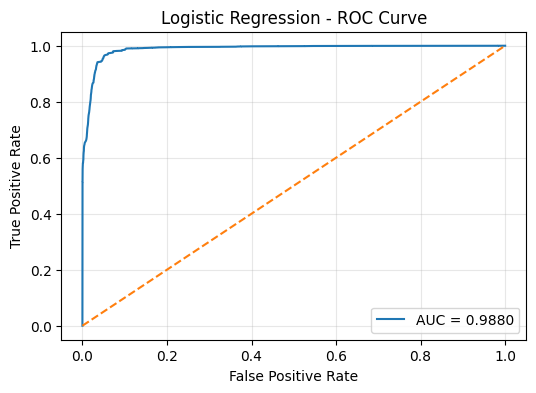

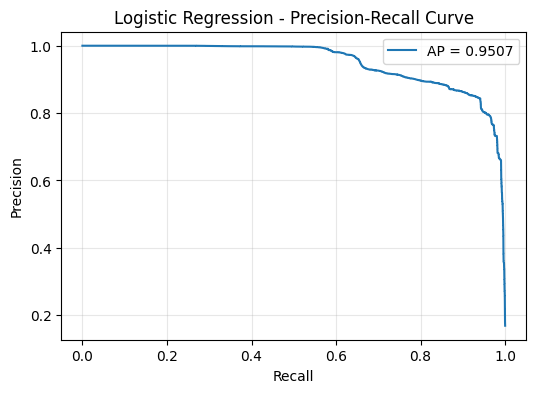

In [17]:
# Logistic Regression plots

plot_binary_confusion_matrix(y_test_bin, y_pred_log, "Logistic Regression - Confusion Matrix")
plot_roc(y_test_bin, y_prob_log, "Logistic Regression - ROC Curve")
plot_pr(y_test_bin, y_prob_log, "Logistic Regression - Precision-Recall Curve")

## Logisitic Regression with SMOTE

In [18]:
log_model_smote = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

log_scaler_smote = StandardScaler()

log_metrics_smote, y_pred_log_smote, y_prob_log_smote, log_train_time_smote = evaluate_binary_model(
    model=log_model_smote,
    X_train=X_train_bin_smote,
    X_test=X_test_bin,
    y_train=y_train_bin_smote,
    y_test=y_test_bin,
    model_name="Logistic Regression (SMOTE)",
    scaler=log_scaler_smote
)

print("Logistic Regression (SMOTE) Results:")
for k, v in log_metrics_smote.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_log_smote, target_names=["BENIGN", "ATTACK"]))

Logistic Regression (SMOTE) Results:
Model: Logistic Regression (SMOTE)
Accuracy: 0.9409
Precision: 0.7498
Recall: 0.9758
F1-Score: 0.8480
Training Time: 410.7506
ROC-AUC: 0.9883
PR-AUC: 0.9496

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.93      0.96    419012
      ATTACK       0.75      0.98      0.85     85148

    accuracy                           0.94    504160
   macro avg       0.87      0.95      0.91    504160
weighted avg       0.95      0.94      0.94    504160



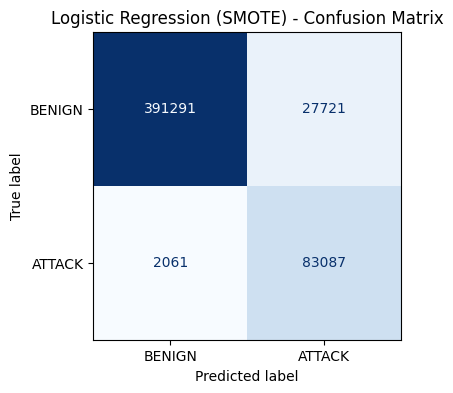

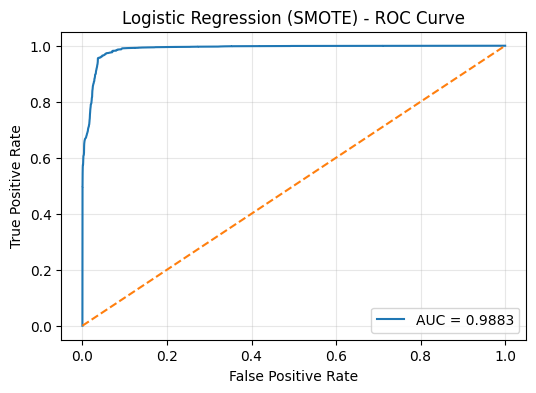

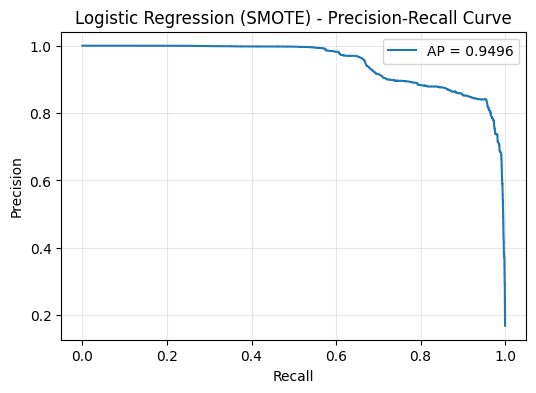

In [19]:
plot_binary_confusion_matrix(
    y_test_bin, y_pred_log_smote,
    "Logistic Regression (SMOTE) - Confusion Matrix"
)

plot_roc(
    y_test_bin, y_prob_log_smote,
    "Logistic Regression (SMOTE) - ROC Curve"
)

plot_pr(
    y_test_bin, y_prob_log_smote,
    "Logistic Regression (SMOTE) - Precision-Recall Curve"
)

## Random Forest

In [20]:

# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

rf_metrics, y_pred_rf, y_prob_rf, rf_train_time = evaluate_binary_model(
    model=rf_model,
    X_train=X_train_bin,
    X_test=X_test_bin,
    y_train=y_train_bin,
    y_test=y_test_bin,
    model_name="Random Forest",
    scaler=None
)

print("Random Forest Results:")
for k, v in rf_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_rf, target_names=["BENIGN", "ATTACK"]))

Random Forest Results:
Model: Random Forest
Accuracy: 0.9985
Precision: 0.9965
Recall: 0.9946
F1-Score: 0.9956
Training Time: 350.2794
ROC-AUC: 0.9998
PR-AUC: 0.9980

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419012
      ATTACK       1.00      0.99      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



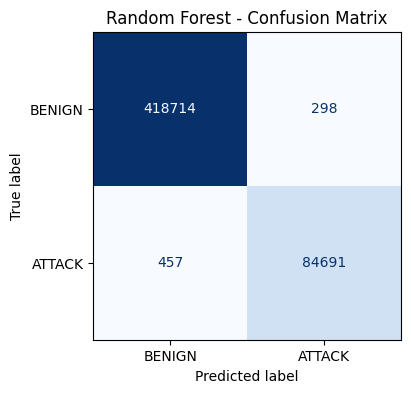

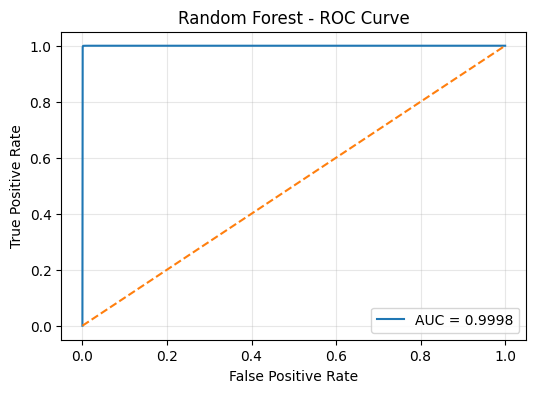

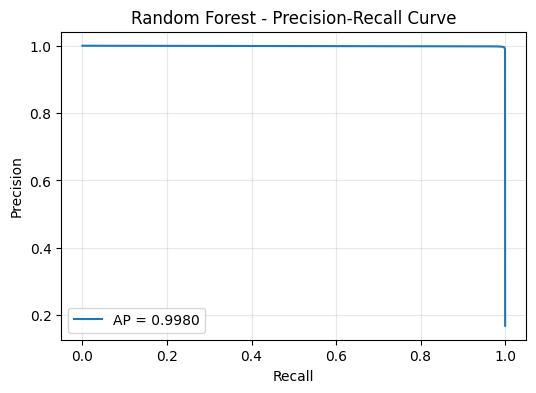

In [21]:

# Random Forest Visuals


plot_binary_confusion_matrix(y_test_bin, y_pred_rf, "Random Forest - Confusion Matrix")
plot_roc(y_test_bin, y_prob_rf, "Random Forest - ROC Curve")
plot_pr(y_test_bin, y_prob_rf, "Random Forest - Precision-Recall Curve")

## Random Forest with SMOTE

In [22]:
rf_model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

rf_metrics_smote, y_pred_rf_smote, y_prob_rf_smote, rf_train_time_smote = evaluate_binary_model(
    model=rf_model_smote,
    X_train=X_train_bin_smote,   # ← SMOTE DATA
    X_test=X_test_bin,
    y_train=y_train_bin_smote,   # ← SMOTE LABELS
    y_test=y_test_bin,
    model_name="Random Forest (SMOTE)",
    scaler=None
)

print("Random Forest (SMOTE) Results:")
for k, v in rf_metrics_smote.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_rf_smote, target_names=["BENIGN", "ATTACK"]))

Random Forest (SMOTE) Results:
Model: Random Forest (SMOTE)
Accuracy: 0.9985
Precision: 0.9954
Recall: 0.9959
F1-Score: 0.9956
Training Time: 574.5697
ROC-AUC: 0.9997
PR-AUC: 0.9976

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419012
      ATTACK       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



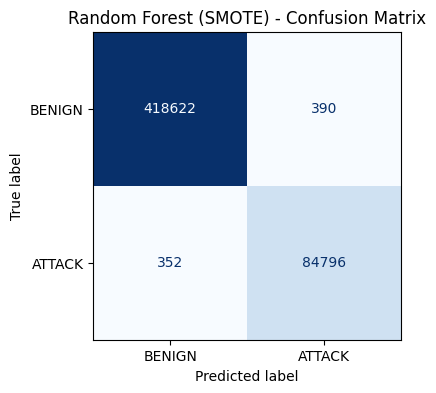

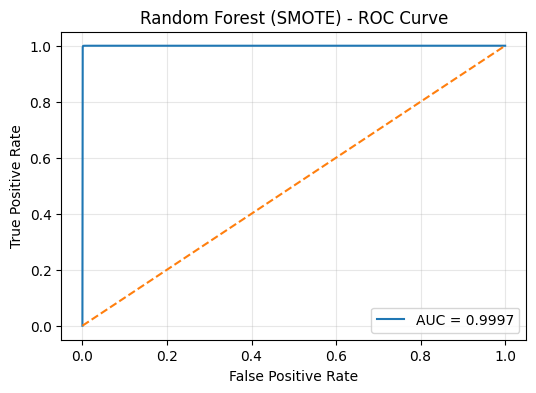

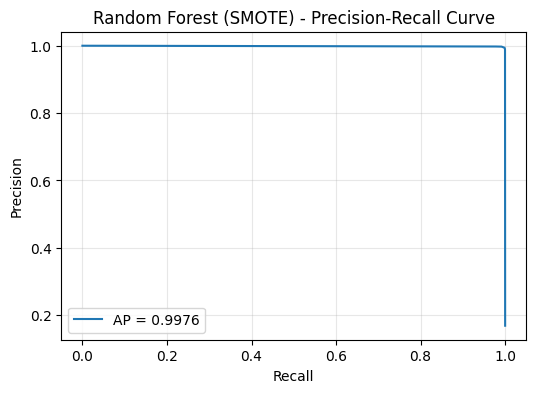

In [23]:
plot_binary_confusion_matrix(
    y_test_bin, y_pred_rf_smote,
    "Random Forest (SMOTE) - Confusion Matrix"
)

plot_roc(
    y_test_bin, y_prob_rf_smote,
    "Random Forest (SMOTE) - ROC Curve"
)

plot_pr(
    y_test_bin, y_prob_rf_smote,
    "Random Forest (SMOTE) - Precision-Recall Curve"
)

## Comparisons

In [24]:

# Model Comparison between Logistic Regression and Random Forest

binary_results_df = pd.DataFrame([
    log_metrics,
    log_metrics_smote,
    rf_metrics,
    rf_metrics_smote
])

binary_results_df = binary_results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("Binary model comparison:")
display(binary_results_df.round(4))

Binary model comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Training Time,ROC-AUC,PR-AUC
0,Random Forest (SMOTE),0.9985,0.9954,0.9959,0.9956,574.5697,0.9997,0.9976
1,Random Forest,0.9985,0.9965,0.9946,0.9956,350.2794,0.9998,0.9980
2,Logistic Regression,0.9571,0.8819,0.8612,0.8714,125.3853,0.9880,0.9507
3,Logistic Regression (SMOTE),0.9409,0.7498,0.9758,0.8480,410.7506,0.9883,0.9496


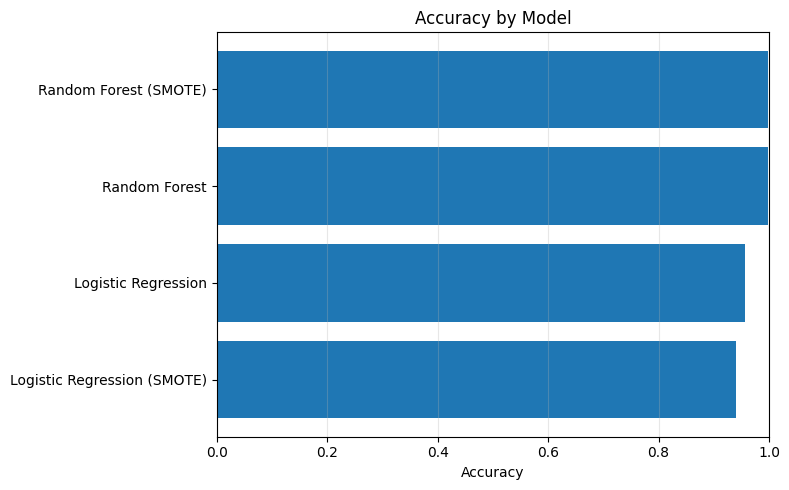

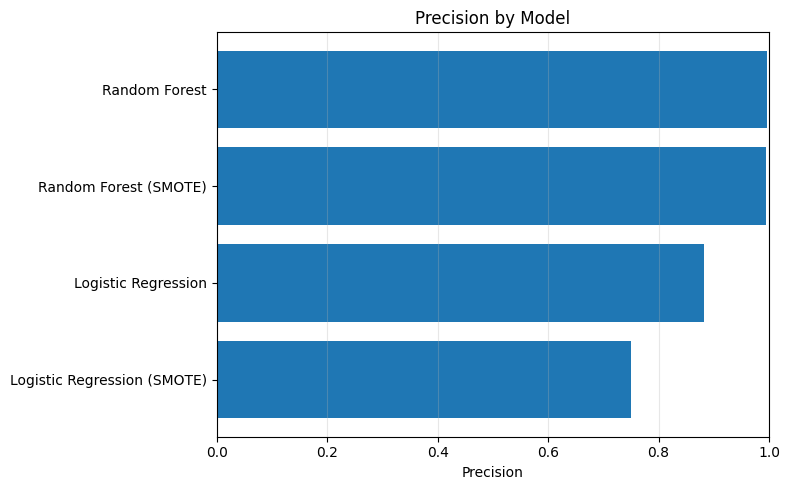

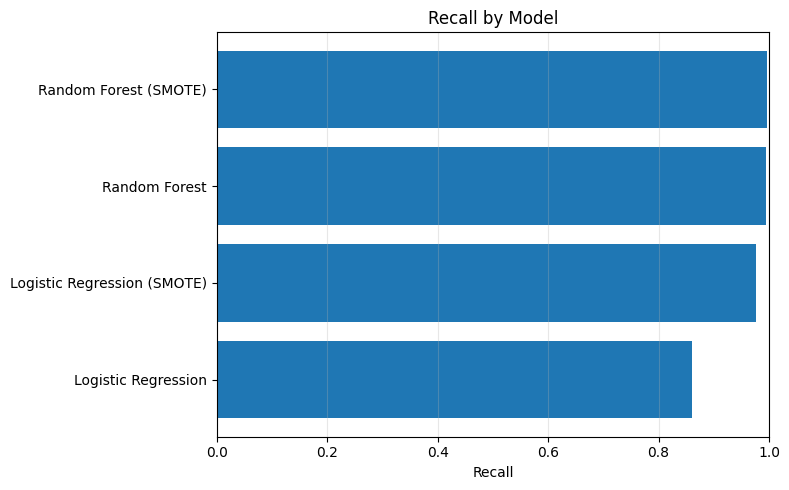

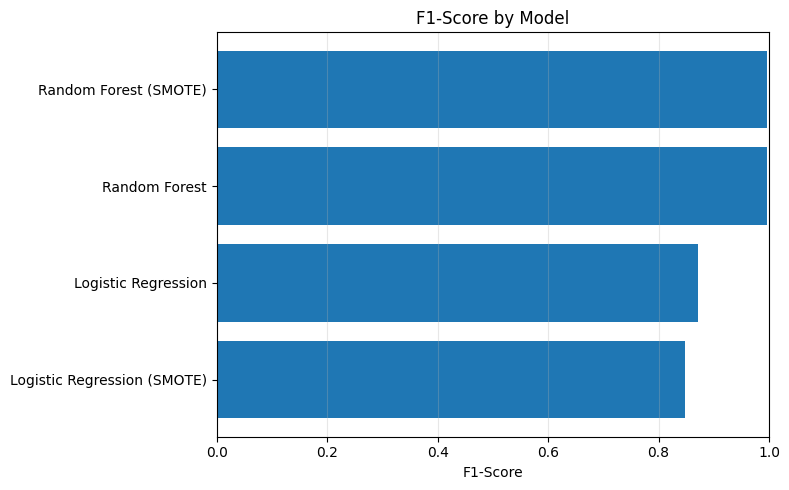

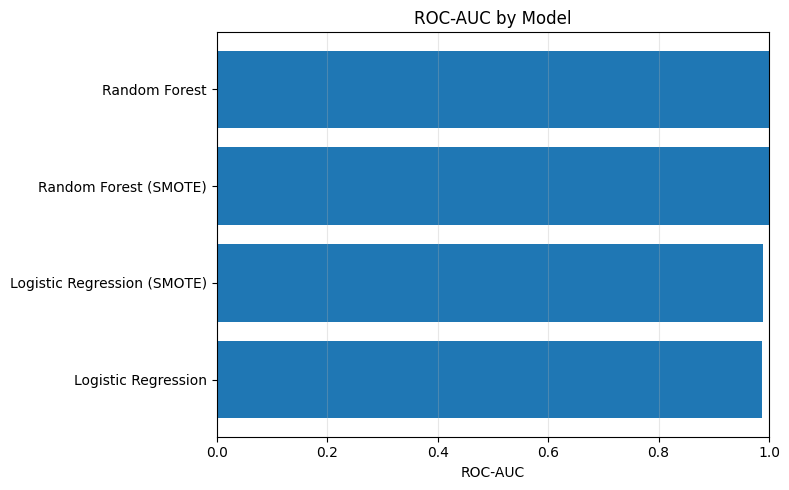

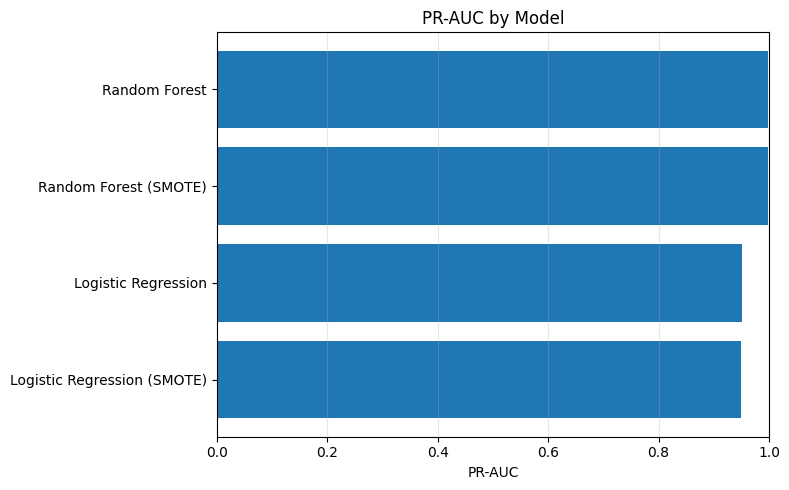

In [25]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))

    df_plot = binary_results_df.sort_values(by=metric)

    plt.barh(df_plot["Model"], df_plot[metric])

    plt.title(f"{metric} by Model")
    plt.xlabel(metric)
    plt.xlim(0, 1)

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plt.show()

In [26]:
# Random Forest Feature Importance

rf_feature_importance = pd.DataFrame({
    "Feature": X_train_bin.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 20 Random Forest Features:")
display(rf_feature_importance.head(20))

Top 20 Random Forest Features:


,Feature,Importance
0,pkt_len_var,0.064565
1,bwd_seg_size_avg,0.064174
2,bwd_pkt_len_std,0.059555
3,bwd_pkt_len_mean,0.058365
4,pkt_len_std,0.051703
5,bwd_pkt_len_max,0.049527
6,pkt_size_avg,0.040610
7,pkt_len_max,0.038957
8,totlen_bwd_pkts,0.037830
9,dst_port,0.029016


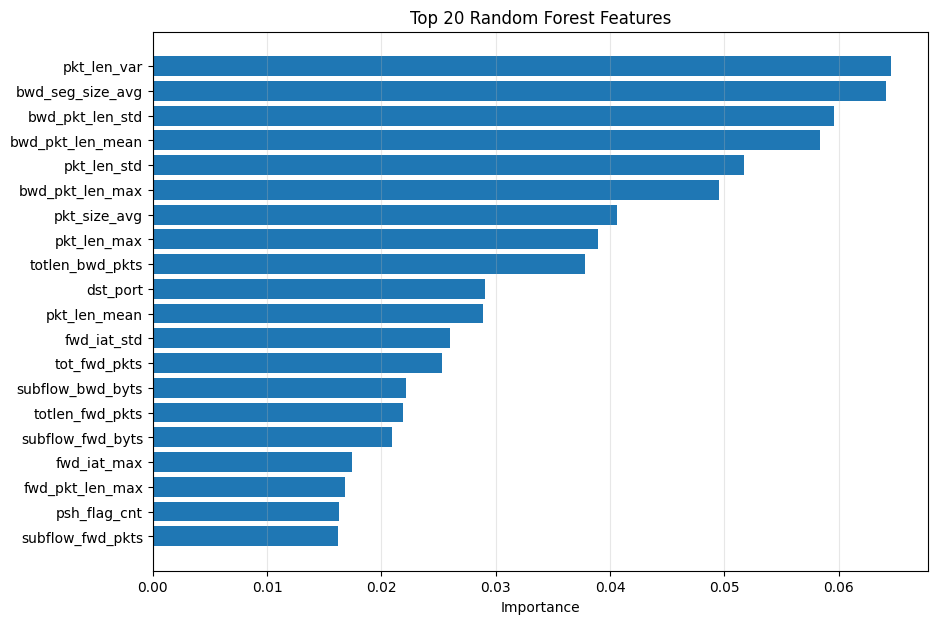

In [27]:
# Plot Top Random Forest Features

top_n = 20
top_features_plot = rf_feature_importance.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(top_features_plot["Feature"][::-1], top_features_plot["Importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Random Forest Features")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [28]:
# Save Binary Artifacts and Exports

# Save feature importance
rf_feature_importance.to_csv(os.path.join(RESULTS_PATH, "feature_importance.csv"), index=False)

# Save models and scaler
joblib.dump(rf_model, os.path.join(MODELS_PATH, "random_forest_model.pkl"))
joblib.dump(log_model, os.path.join(MODELS_PATH, "logistic_regression_model.pkl"))
joblib.dump(log_scaler, os.path.join(MODELS_PATH, "standard_scaler.pkl"))

# Save test samples for frontend
sample_size = min(50000, len(X_test_bin))

X_test_sample = X_test_bin.sample(sample_size, random_state=SEED)
y_test_sample = y_test_bin.loc[X_test_sample.index]

X_test_sample = X_test_sample.astype("float32")

X_test_sample.to_csv(os.path.join(ARTIFACTS_PATH, "X_test_sample.csv"), index=False)
y_test_sample.to_csv(os.path.join(ARTIFACTS_PATH, "y_test_sample.csv"), index=False)

print("Saved X_test_sample rows:", len(X_test_sample))
print("Saved binary model artifacts successfully.")

Saved X_test_sample rows: 50000
Saved binary model artifacts successfully.


## Deep Learning

In [29]:
# Deep Learning Imports

import tensorflow as tf

Sequential = tf.keras.models.Sequential
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
Input = tf.keras.layers.Input
EarlyStopping = tf.keras.callbacks.EarlyStopping

tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1778096827.313902    1272 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU: []


W0000 00:00:1778096833.093226    1272 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [30]:
# Prepare Scaled Data for Deep Learning

dl_scaler = StandardScaler()

X_train_bin_dl = dl_scaler.fit_transform(X_train_bin)
X_test_bin_dl = dl_scaler.transform(X_test_bin)

print("Binary DL train shape:", X_train_bin_dl.shape)
print("Binary DL test shape:", X_test_bin_dl.shape)

Binary DL train shape: (2016638, 77)
Binary DL test shape: (504160, 77)


In [31]:
# Build Binary Deep Learning Model

dl_model = Sequential([
    Input(shape=(X_train_bin_dl.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,305 (71.50 KB)

 Trainable params: 18,305 (71.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train Binary Deep Learning Model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_dl = time.time()

history = dl_model.fit(
    X_train_bin_dl,
    y_train_bin,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

end_dl = time.time()
dl_training_time = end_dl - start_dl

print(f"Deep Learning training time: {dl_training_time:.2f} seconds")

Epoch 1/15


W0000 00:00:1778096836.174817    1272 cpu_allocator_impl.cc:82] Allocation of 496899480 exceeds 10% of free system memory.


6287/6302 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9598 - loss: 0.0935

W0000 00:00:1778096859.403599    1272 cpu_allocator_impl.cc:82] Allocation of 124225024 exceeds 10% of free system memory.


6302/6302 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9714 - loss: 0.0658 - val_accuracy: 0.9795 - val_loss: 0.0455
Epoch 2/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9792 - loss: 0.0460 - val_accuracy: 0.9802 - val_loss: 0.0408
Epoch 3/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9807 - loss: 0.0421 - val_accuracy: 0.9817 - val_loss: 0.0359
Epoch 4/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9816 - loss: 0.0402 - val_accuracy: 0.9811 - val_loss: 0.0378
Epoch 5/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9818 - loss: 0.0396 - val_accuracy: 0.9840 - val_loss: 0.0338
Epoch 6/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9825 - loss: 0.0382 - val_accuracy: 0.9819 - val_loss: 0.0353
Epoch 7/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9828 - loss: 0.0378 - val_accuracy: 0.9823 - val_loss: 0.0373
Epoch 8/15
6302/6302 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9830 - loss: 0.0374 - val

In [33]:
# Evaluate Binary Deep Learning Model

y_prob_dl = dl_model.predict(X_test_bin_dl).flatten()
y_pred_dl = (y_prob_dl >= 0.5).astype(int)

dl_metrics = {
    "Model": "Deep Learning",
    "Accuracy": accuracy_score(y_test_bin, y_pred_dl),
    "Precision": precision_score(y_test_bin, y_pred_dl, zero_division=0),
    "Recall": recall_score(y_test_bin, y_pred_dl, zero_division=0),
    "F1-Score": f1_score(y_test_bin, y_pred_dl, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_bin, y_prob_dl),
    "PR-AUC": average_precision_score(y_test_bin, y_prob_dl),
    "Training Time": dl_training_time
}

print("Deep Learning Results:")
for k, v in dl_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_dl, target_names=["BENIGN", "ATTACK"]))

  121/15755 ━━━━━━━━━━━━━━━━━━━━ 13s 838us/step

W0000 00:00:1778097020.330418    1272 cpu_allocator_impl.cc:82] Allocation of 155281280 exceeds 10% of free system memory.


15755/15755 ━━━━━━━━━━━━━━━━━━━━ 12s 778us/step
Deep Learning Results:
Model: Deep Learning
Accuracy: 0.9840
Precision: 0.9606
Recall: 0.9439
F1-Score: 0.9522
ROC-AUC: 0.9987
PR-AUC: 0.9940
Training Time: 184.1810

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.99      0.99    419012
      ATTACK       0.96      0.94      0.95     85148

    accuracy                           0.98    504160
   macro avg       0.97      0.97      0.97    504160
weighted avg       0.98      0.98      0.98    504160



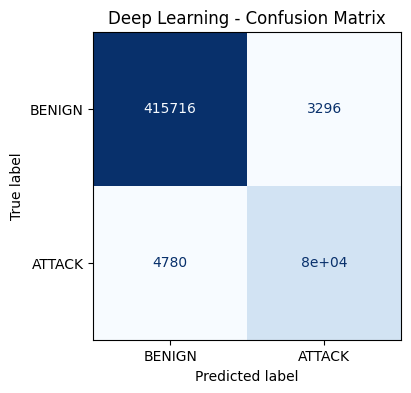

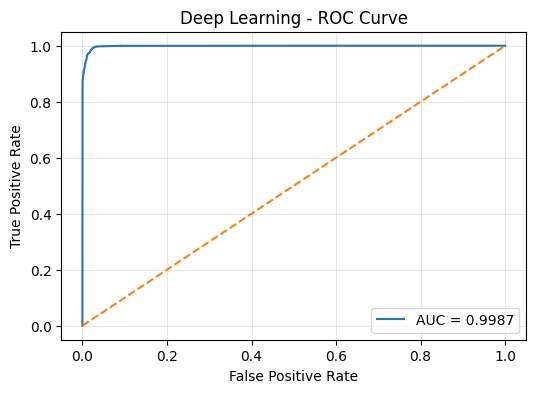

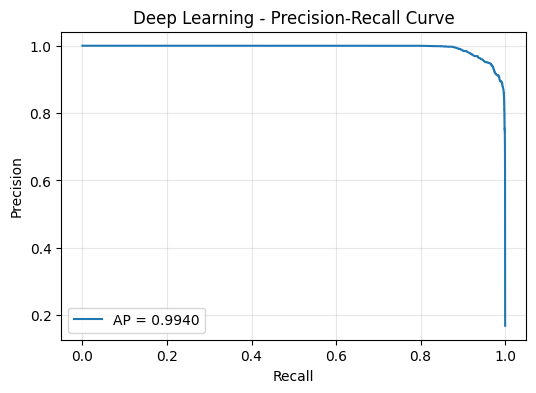

In [34]:
# Deep Learning Visuals

plot_binary_confusion_matrix(y_test_bin, y_pred_dl, "Deep Learning - Confusion Matrix")
plot_roc(y_test_bin, y_prob_dl, "Deep Learning - ROC Curve")
plot_pr(y_test_bin, y_prob_dl, "Deep Learning - Precision-Recall Curve")

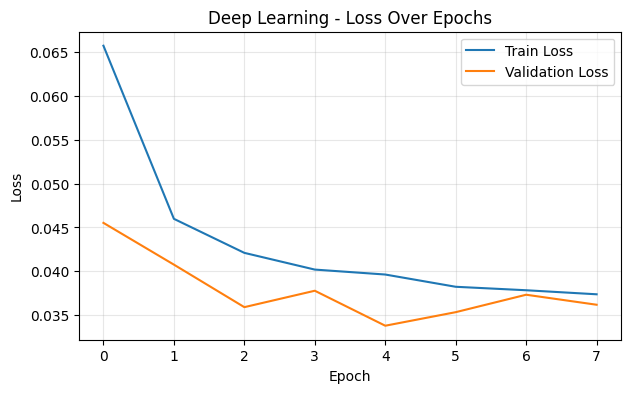

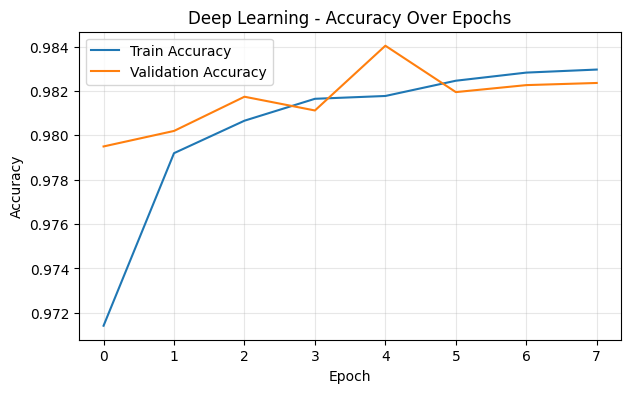

In [35]:
# Deep Learning Training Curves

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Deep Learning - Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deep Learning - Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
# Update Binary Comparison Table

binary_results_df = pd.DataFrame([
    log_metrics,
    log_metrics_smote,
    rf_metrics,
    rf_metrics_smote,
    dl_metrics
])
binary_results_df = binary_results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("Updated binary model comparison:")
display(binary_results_df.round(4))

Updated binary model comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Training Time,ROC-AUC,PR-AUC
0,Random Forest (SMOTE),0.9985,0.9954,0.9959,0.9956,574.5697,0.9997,0.9976
1,Random Forest,0.9985,0.9965,0.9946,0.9956,350.2794,0.9998,0.9980
2,Deep Learning,0.9840,0.9606,0.9439,0.9522,184.1810,0.9987,0.9940
3,Logistic Regression,0.9571,0.8819,0.8612,0.8714,125.3853,0.9880,0.9507
4,Logistic Regression (SMOTE),0.9409,0.7498,0.9758,0.8480,410.7506,0.9883,0.9496


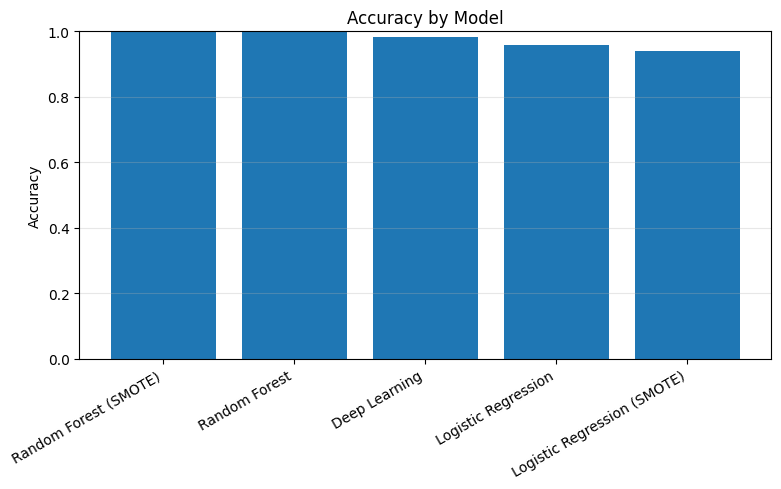

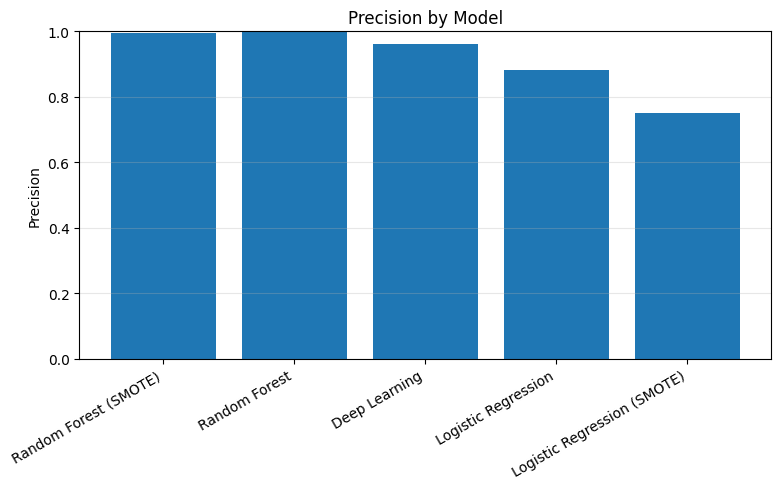

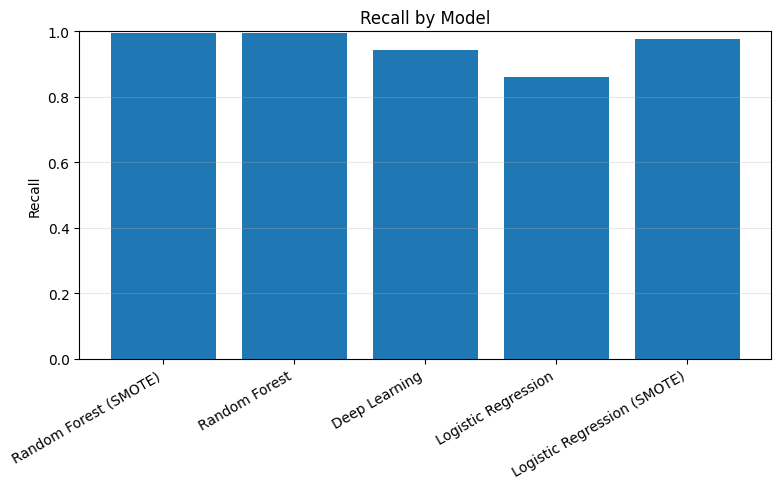

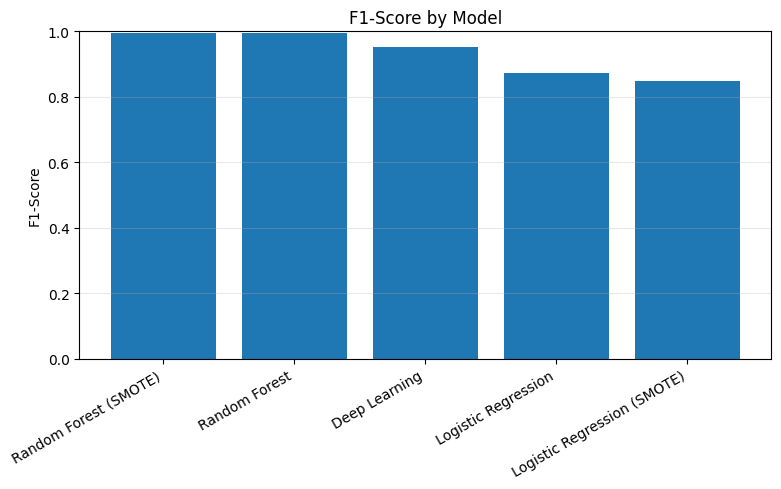

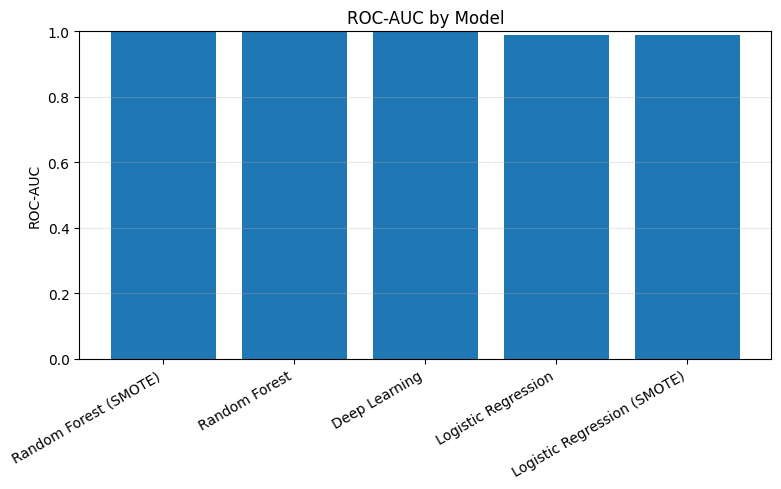

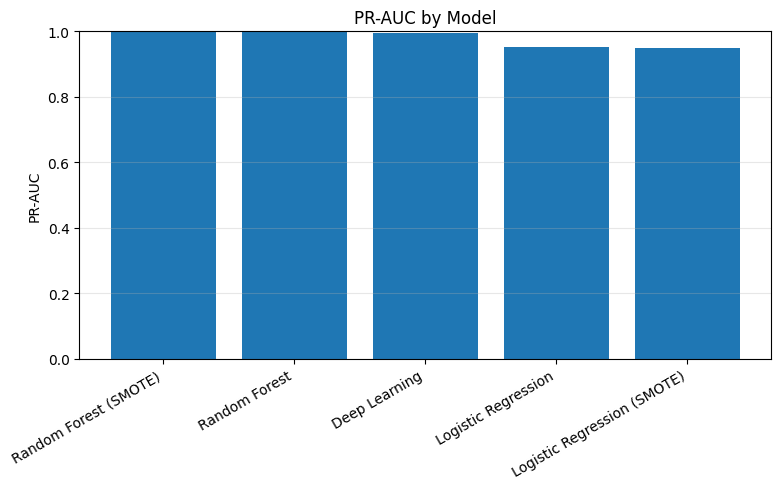

In [37]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(binary_results_df["Model"], binary_results_df[metric])

    plt.title(f"{metric} by Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)

    plt.xticks(rotation=30, ha="right")  # ← FIX

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    plt.show()

In [38]:
# Multi-Class Random Forest

rf_multi_model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

start_multi = time.time()
rf_multi_model.fit(X_train_multi, y_train_multi_enc)
end_multi = time.time()

multi_training_time = end_multi - start_multi

y_pred_multi_enc = rf_multi_model.predict(X_test_multi)
y_pred_multi = multi_label_encoder.inverse_transform(y_pred_multi_enc)

multi_accuracy = accuracy_score(y_test_multi, y_pred_multi)
multi_precision = precision_score(y_test_multi, y_pred_multi, average="weighted", zero_division=0)
multi_recall = recall_score(y_test_multi, y_pred_multi, average="weighted", zero_division=0)
multi_f1 = f1_score(y_test_multi, y_pred_multi, average="weighted", zero_division=0)

multi_metrics = {
    "Model": "Random Forest Multi-Class",
    "Accuracy": multi_accuracy,
    "Precision": multi_precision,
    "Recall": multi_recall,
    "F1-Score": multi_f1,
    "Training Time": multi_training_time
}

print("Multi-Class Random Forest Results:")
for k, v in multi_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

Multi-Class Random Forest Results:
Model: Random Forest Multi-Class
Accuracy: 0.9982
Precision: 0.9982
Recall: 0.9982
F1-Score: 0.9982
Training Time: 279.5898


In [39]:
# Multi-Class Classification Report

print("Multi-Class Classification Report:")
print(classification_report(y_test_multi, y_pred_multi, zero_division=0))

Multi-Class Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419012
         Bot       0.86      0.75      0.80       390
  BruteForce       0.96      0.96      0.96      2124
    DoS/DDoS       1.00      1.00      1.00     64352
  Heartbleed       1.00      1.00      1.00         2
Infiltration       1.00      0.86      0.92         7
    PortScan       0.99      0.99      0.99     18139
   WebAttack       0.35      0.30      0.32       134

    accuracy                           1.00    504160
   macro avg       0.90      0.86      0.87    504160
weighted avg       1.00      1.00      1.00    504160



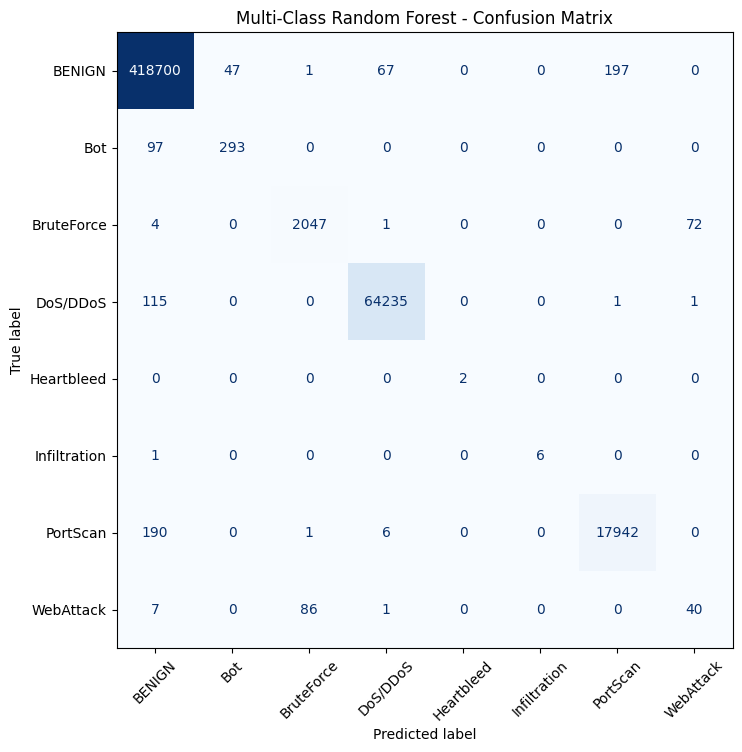

In [40]:
# Multi-Class Confusion Matrix

cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=multi_label_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=multi_label_encoder.classes_
)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Multi-Class Random Forest - Confusion Matrix")
plt.show()

In [41]:
# Multi-Class Feature Importance

rf_multi_feature_importance = pd.DataFrame({
    "Feature": X_train_multi.columns,
    "Importance": rf_multi_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 20 Multi-Class Features:")
display(rf_multi_feature_importance.head(20))

Top 20 Multi-Class Features:


,Feature,Importance
0,pkt_len_var,0.073660
1,bwd_pkt_len_std,0.065921
2,bwd_seg_size_avg,0.063971
3,bwd_pkt_len_mean,0.061541
4,pkt_len_std,0.050076
5,bwd_pkt_len_max,0.043662
6,pkt_size_avg,0.038887
7,pkt_len_mean,0.036080
8,pkt_len_max,0.034689
9,totlen_bwd_pkts,0.034025


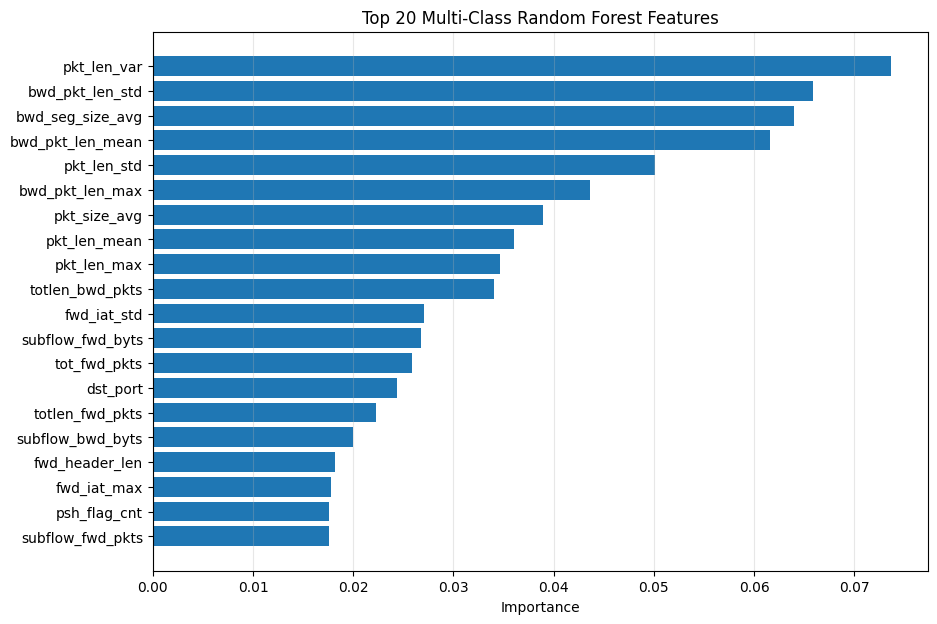

In [42]:
# Plot Top Multi-Class Features

top_n_multi = 20
top_multi_features_plot = rf_multi_feature_importance.head(top_n_multi)

plt.figure(figsize=(10, 7))
plt.barh(top_multi_features_plot["Feature"][::-1], top_multi_features_plot["Importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n_multi} Multi-Class Random Forest Features")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [43]:
# Save Additional Artifacts for Multi-Class Model and Deep Learning Model

# Update binary comparison CSV with DL included
binary_results_df.to_csv(os.path.join(RESULTS_PATH, "model_comparison.csv"), index=False)

# Save multi-class metrics
multi_results_df = pd.DataFrame([multi_metrics])
multi_results_df.to_csv(os.path.join(RESULTS_PATH, "multiclass_model_comparison.csv"), index=False)

# Save multi-class feature importance
rf_multi_feature_importance.to_csv(
    os.path.join(RESULTS_PATH, "multiclass_feature_importance.csv"),
    index=False
)

# Save multi-class model
joblib.dump(rf_multi_model, os.path.join(MODELS_PATH, "random_forest_multiclass_model.pkl"))

# Save DL scaler separately
joblib.dump(dl_scaler, os.path.join(MODELS_PATH, "deep_learning_scaler.pkl"))

# Save DL model
dl_model.save(os.path.join(MODELS_PATH, "deep_learning_model.keras"))

print("Artifacts saved successfully.")

Artifacts saved successfully.


## Anomaly Detection

In [44]:
# Anomaly Detection with Isolation Forest

# Train only on benign traffic to make anomaly detection more realistic
X_train_benign = X_train_bin[y_train_bin == 0].copy()

iso_scaler = StandardScaler()
X_train_benign_scaled = iso_scaler.fit_transform(X_train_benign)
X_test_bin_scaled_for_iso = iso_scaler.transform(X_test_bin)

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=SEED,
    n_jobs=-1
)

start_iso = time.time()
iso_model.fit(X_train_benign_scaled)
end_iso = time.time()
iso_training_time = end_iso - start_iso

# IsolationForest: predict() returns 1 for normal, -1 for anomaly
iso_pred_raw = iso_model.predict(X_test_bin_scaled_for_iso)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

# decision_function: higher = more normal, lower = more anomalous
iso_scores_raw = iso_model.decision_function(X_test_bin_scaled_for_iso)

# convert to anomaly like score where higher means more suspicious
iso_anomaly_score = -iso_scores_raw

iso_metrics = {
    "Model": "Isolation Forest",
    "Accuracy": accuracy_score(y_test_bin, iso_pred),
    "Precision": precision_score(y_test_bin, iso_pred, zero_division=0),
    "Recall": recall_score(y_test_bin, iso_pred, zero_division=0),
    "F1-Score": f1_score(y_test_bin, iso_pred, zero_division=0),
    "Training Time": iso_training_time
}

print("Isolation Forest Results:")
for k, v in iso_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nClassification Report:")
print(classification_report(y_test_bin, iso_pred, target_names=["BENIGN", "ATTACK"]))

Isolation Forest Results:
Model: Isolation Forest
Accuracy: 0.8482
Precision: 0.5465
Recall: 0.5939
F1-Score: 0.5692
Training Time: 6.1530

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.92      0.90      0.91    419012
      ATTACK       0.55      0.59      0.57     85148

    accuracy                           0.85    504160
   macro avg       0.73      0.75      0.74    504160
weighted avg       0.85      0.85      0.85    504160



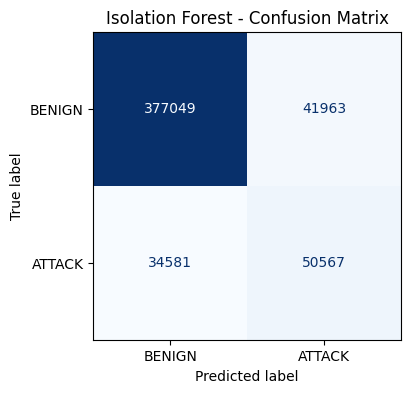

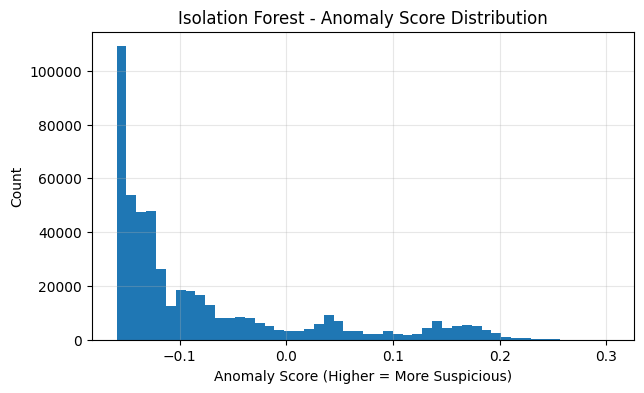

In [45]:
# Isolation Forest Visuals

plot_binary_confusion_matrix(y_test_bin, iso_pred, "Isolation Forest - Confusion Matrix")

plt.figure(figsize=(7, 4))
plt.hist(iso_anomaly_score, bins=50)
plt.title("Isolation Forest - Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Higher = More Suspicious)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

In [46]:
# Add Isolation Forest to the full comparison

full_results_df = pd.DataFrame([
    log_metrics,
    log_metrics_smote,
    rf_metrics,
    rf_metrics_smote,
    dl_metrics,
    iso_metrics
])

full_results_df = full_results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("Full comparison including SMOTE and anomaly detection:")
display(full_results_df.round(4))

Full comparison including SMOTE and anomaly detection:


,Model,Accuracy,Precision,Recall,F1-Score,Training Time,ROC-AUC,PR-AUC
0,Random Forest (SMOTE),0.9985,0.9954,0.9959,0.9956,574.5697,0.9997,0.9976
1,Random Forest,0.9985,0.9965,0.9946,0.9956,350.2794,0.9998,0.9980
2,Deep Learning,0.9840,0.9606,0.9439,0.9522,184.1810,0.9987,0.9940
3,Logistic Regression,0.9571,0.8819,0.8612,0.8714,125.3853,0.9880,0.9507
4,Logistic Regression (SMOTE),0.9409,0.7498,0.9758,0.8480,410.7506,0.9883,0.9496
5,Isolation Forest,0.8482,0.5465,0.5939,0.5692,6.1530,NaN,NaN


## SHAP Explainability

In [47]:
# SHAP Summary for Random Forest

# Use a sample for speed
shap_sample_size = min(1000, len(X_test_bin))
X_shap_sample = X_test_bin.sample(n=shap_sample_size, random_state=SEED)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

print("Computed SHAP values.")

Computed SHAP values.


Final SHAP shape: (1000, 77)


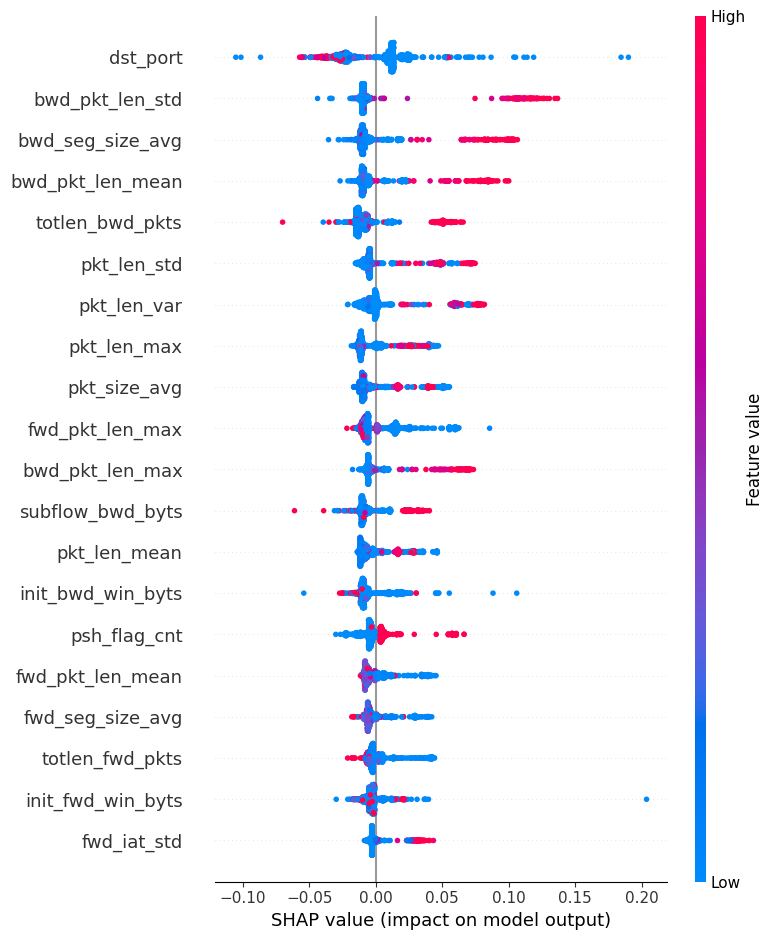

In [48]:
# Normalize SHAP output (use once everywhere)

if isinstance(shap_values, list):
    shap_array = shap_values[1]  # positive class (ATTACK)
else:
    shap_array = shap_values

shap_array = np.array(shap_array)

# Handle 3D case
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1] if shap_array.shape[2] == 2 else shap_array[:, :, 0]

print("Final SHAP shape:", shap_array.shape)

# SHAP plots
shap.summary_plot(shap_array, X_shap_sample)

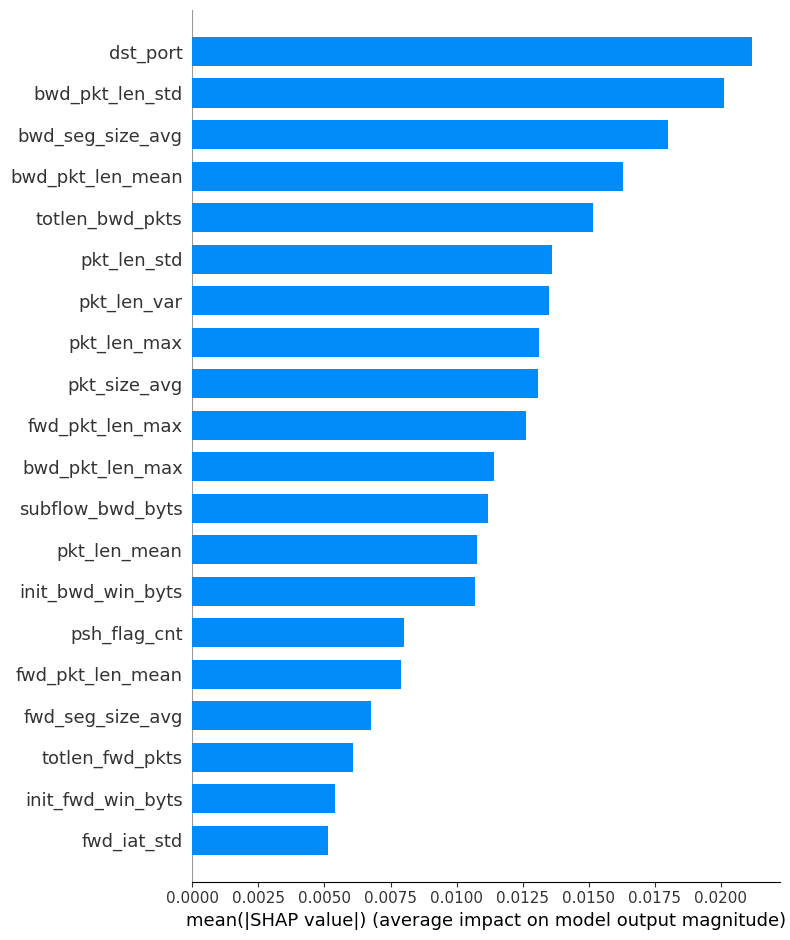

In [49]:
# SHAP Bar Plot

shap.summary_plot(shap_array, X_shap_sample, plot_type="bar")

In [50]:
# Save Global SHAP Importance

mean_abs_shap = np.abs(shap_array).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_shap_sample.columns.tolist(),
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False).reset_index(drop=True)

print("Top 20 SHAP Features:")
display(shap_importance_df.head(20))

shap_importance_df.to_csv(
    os.path.join(RESULTS_PATH, "shap_feature_importance.csv"),
    index=False
)

Top 20 SHAP Features:


,Feature,MeanAbsSHAP
0,dst_port,0.021182
1,bwd_pkt_len_std,0.020109
2,bwd_seg_size_avg,0.018004
3,bwd_pkt_len_mean,0.016299
4,totlen_bwd_pkts,0.015170
5,pkt_len_std,0.013597
6,pkt_len_var,0.013499
7,pkt_len_max,0.013101
8,pkt_size_avg,0.013067
9,fwd_pkt_len_max,0.012634


In [51]:
# Sample-Level Prediction Explanations

sample_explanations = X_shap_sample.head(10).copy()
sample_preds = rf_model.predict(sample_explanations)
sample_probs = rf_model.predict_proba(sample_explanations)[:, 1]

sample_explanations["Predicted_Label"] = sample_preds
sample_explanations["Attack_Probability"] = sample_probs
sample_explanations["Predicted_Label_Name"] = sample_explanations["Predicted_Label"].map({
    0: "BENIGN",
    1: "ATTACK"
})

print("Saved sample prediction explanations.")
display(sample_explanations.head())

Saved sample prediction explanations.


,dst_port,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,fwd_pkt_len_std,...,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,Predicted_Label,Attack_Probability,Predicted_Label_Name
209012,1233.0,87.0,1.0,1.0,0.0,6.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,1,1.0,ATTACK
1957077,443.0,117189200.0,17.0,16.0,1011.0,5701.0,334.0,0.0,59.470589,91.357208,...,347753.0,590221.0,98424.0,58203852.0,330268.375,58437388.0,57970316.0,0,0.0,BENIGN
2625888,53.0,221.0,2.0,2.0,60.0,416.0,30.0,30.0,30.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0,0.0,BENIGN
1452896,51898.0,204784.0,2.0,3.0,0.0,18.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0,0.0,BENIGN
482692,49809.0,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0,0.0,BENIGN


## Alerts & What-if

In [52]:
# High-Confidence Alert Generation

rf_test_results = X_test_bin.copy()
rf_test_results["True_Label"] = y_test_bin.values
rf_test_results["Predicted_Label"] = y_pred_rf
rf_test_results["Attack_Probability"] = y_prob_rf
rf_test_results["Predicted_Label_Name"] = rf_test_results["Predicted_Label"].map({
    0: "BENIGN",
    1: "ATTACK"
})

# Add multi-class attack category
multi_test_pred_enc = rf_multi_model.predict(X_test_bin)
multi_test_pred_labels = multi_label_encoder.inverse_transform(multi_test_pred_enc)
rf_test_results["Predicted_Attack_Category"] = multi_test_pred_labels

# Add anomaly score
iso_test_scaled = iso_scaler.transform(X_test_bin)
iso_test_scores_raw = iso_model.decision_function(iso_test_scaled)
rf_test_results["Anomaly_Score"] = -iso_test_scores_raw

alert_threshold = 0.90

high_confidence_alerts = rf_test_results[
    (rf_test_results["Predicted_Label"] == 1) &
    (rf_test_results["Attack_Probability"] >= alert_threshold)
].copy()

print(f"High-confidence alerts found: {len(high_confidence_alerts)}")
display(high_confidence_alerts.head())

High-confidence alerts found: 84224


,dst_port,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,fwd_pkt_len_std,...,idle_mean,idle_std,idle_max,idle_min,True_Label,Predicted_Label,Attack_Probability,Predicted_Label_Name,Predicted_Attack_Category,Anomaly_Score
92656,20222.0,50.0,1.0,1.0,2.0,6.0,2.0,2.0,2.000000,0.000000,...,0.0,0.0,0.0,0.0,1,1,1.0,ATTACK,PortScan,-0.138505
207592,49175.0,13.0,1.0,1.0,0.0,6.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1,1,1.0,ATTACK,PortScan,-0.106670
221966,1152.0,95.0,1.0,1.0,0.0,6.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1,1,1.0,ATTACK,PortScan,-0.135210
2504688,80.0,9810724.0,4.0,0.0,24.0,0.0,6.0,6.0,6.000000,0.000000,...,9809726.0,0.0,9809726.0,9809726.0,1,1,1.0,ATTACK,DoS/DDoS,-0.082196
1268746,80.0,83540240.0,7.0,6.0,397.0,11595.0,397.0,0.0,56.714287,150.051895,...,83400000.0,0.0,83400000.0,83400000.0,1,1,1.0,ATTACK,DoS/DDoS,0.153526


In [53]:
# Add Alert Message Field

top_alert_features = rf_feature_importance["Feature"].head(5).tolist()

def generate_alert_message_from_row(row, top_features):
    details = []
    for feature in top_features:
        if feature in row.index:
            value = row[feature]
            if pd.api.types.is_numeric_dtype(pd.Series([value])):
                details.append(f"{feature}={float(value):.2f}")
            else:
                details.append(f"{feature}={value}")
    return (
        f"ALERT: Possible network attack detected | "
        f"Confidence={row.get('Attack_Probability', np.nan):.3f} | "
        f"Predicted={row.get('Predicted_Label_Name', 'UNKNOWN')} | "
        f"Observed values: {', '.join(details)}"
    )

high_confidence_alerts["Alert_Message"] = high_confidence_alerts.apply(
    lambda row: generate_alert_message_from_row(row, top_alert_features),
    axis=1
)

display(high_confidence_alerts[["Attack_Probability", "Predicted_Label_Name", "Alert_Message"]].head())

,Attack_Probability,Predicted_Label_Name,Alert_Message
92656,1.0,ATTACK,ALERT: Possible network attack detected | Conf...
207592,1.0,ATTACK,ALERT: Possible network attack detected | Conf...
221966,1.0,ATTACK,ALERT: Possible network attack detected | Conf...
2504688,1.0,ATTACK,ALERT: Possible network attack detected | Conf...
1268746,1.0,ATTACK,ALERT: Possible network attack detected | Conf...


In [54]:
# Save Alerts and What-If Metadata

high_confidence_alerts.to_csv(
    os.path.join(RESULTS_PATH, "high_confidence_alerts.csv"),
    index=False
)

what_if_features = rf_feature_importance["Feature"].head(8).tolist()
joblib.dump(what_if_features, os.path.join(ARTIFACTS_PATH, "what_if_features.pkl"))

print("Saved alerts and what-if feature list.")
print("Top editable what-if features:", what_if_features)

Saved alerts and what-if feature list.
Top editable what-if features: ['pkt_len_var', 'bwd_seg_size_avg', 'bwd_pkt_len_std', 'bwd_pkt_len_mean', 'pkt_len_std', 'bwd_pkt_len_max', 'pkt_size_avg', 'pkt_len_max']


## Concept Drift

In [55]:
# Concept Drift Analysis

# Sort by original index order as a simple sequence proxy
X_drift = X_test_bin.reset_index(drop=True).copy()
y_drift = y_test_bin.reset_index(drop=True).copy()

n_chunks = 5
chunk_size = len(X_drift) // n_chunks

drift_results = []

for i in range(n_chunks):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size if i < n_chunks - 1 else len(X_drift)

    X_chunk = X_drift.iloc[start_idx:end_idx]
    y_chunk = y_drift.iloc[start_idx:end_idx]

    y_pred_chunk = rf_model.predict(X_chunk)
    y_prob_chunk = rf_model.predict_proba(X_chunk)[:, 1]

    drift_results.append({
        "Test_Chunk": f"Chunk_{i+1}",
        "Accuracy": accuracy_score(y_chunk, y_pred_chunk),
        "Precision": precision_score(y_chunk, y_pred_chunk, zero_division=0),
        "Recall": recall_score(y_chunk, y_pred_chunk, zero_division=0),
        "F1-Score": f1_score(y_chunk, y_pred_chunk, zero_division=0),
        "ROC-AUC": roc_auc_score(y_chunk, y_prob_chunk),
        "PR-AUC": average_precision_score(y_chunk, y_prob_chunk)
    })

concept_drift_df = pd.DataFrame(drift_results)

print("Concept drift results:")
display(concept_drift_df.round(4))

Concept drift results:


,Test_Chunk,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Chunk_1,0.9984,0.9962,0.9945,0.9953,0.9998,0.9981
1,Chunk_2,0.9985,0.9963,0.9948,0.9955,0.9998,0.9978
2,Chunk_3,0.9987,0.9975,0.9949,0.9962,0.9998,0.9984
3,Chunk_4,0.9984,0.9964,0.9941,0.9952,0.9998,0.9980
4,Chunk_5,0.9985,0.9961,0.9949,0.9955,0.9998,0.9979


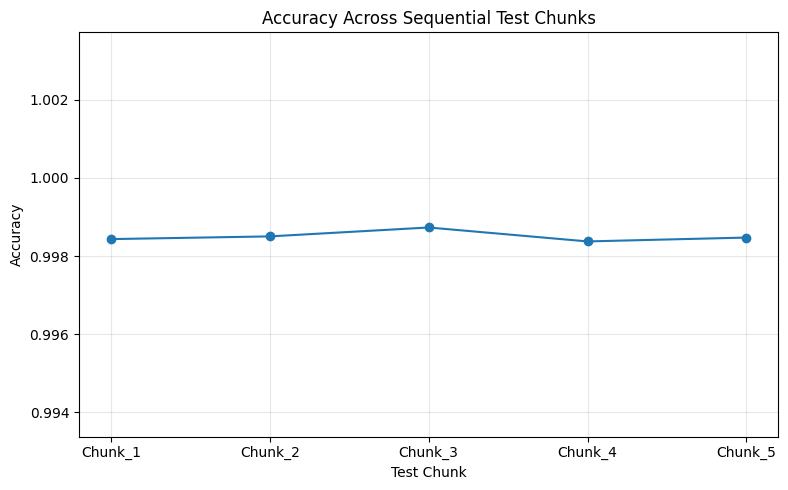

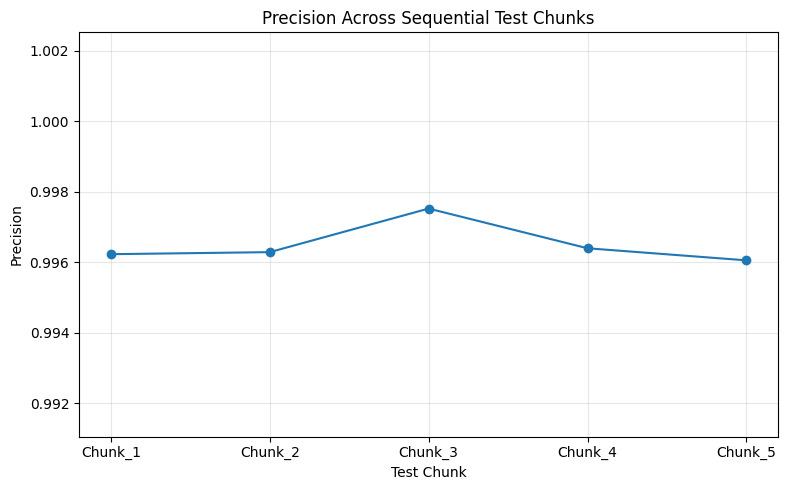

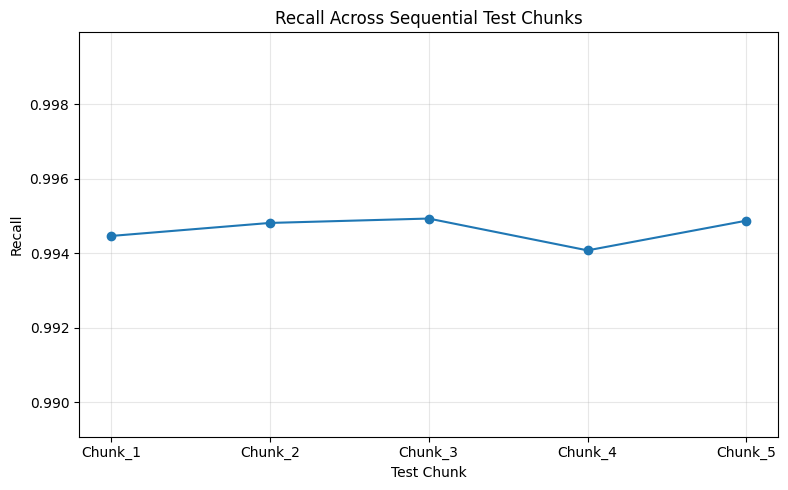

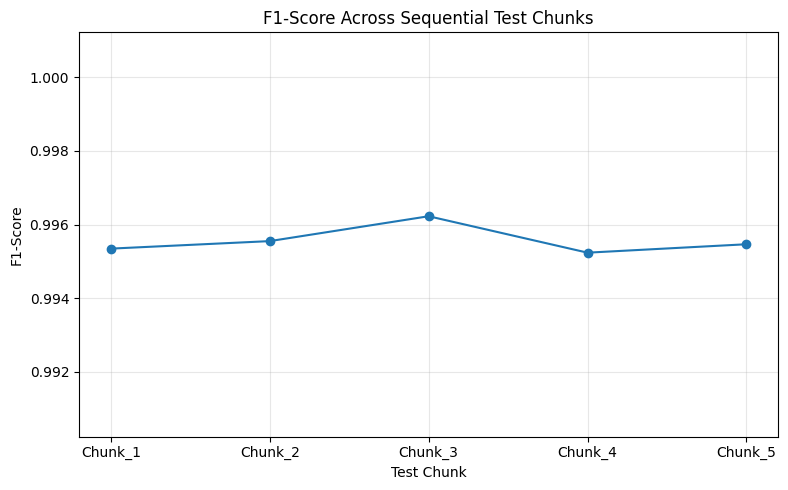

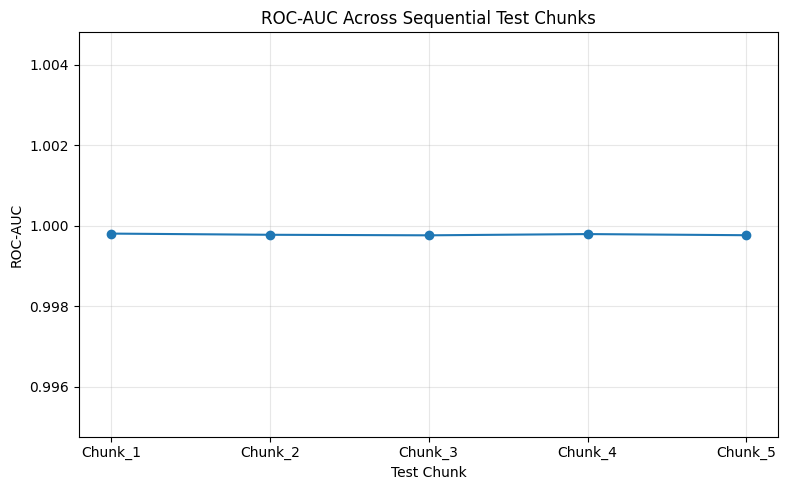

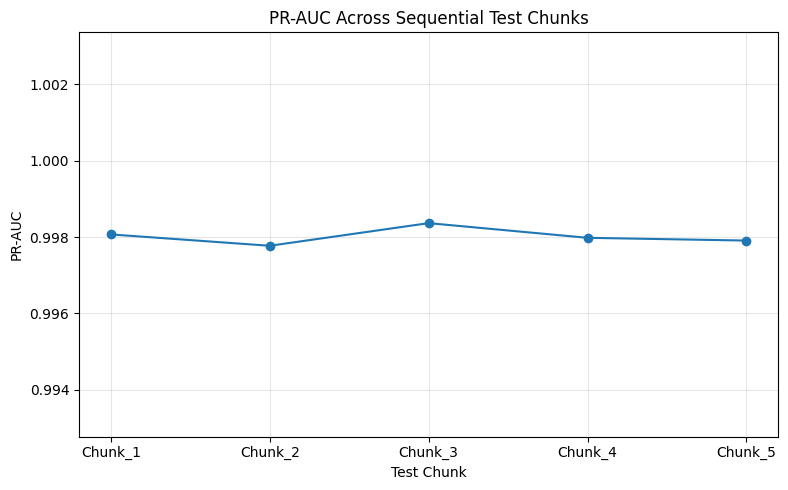

In [56]:
# Plot concept drift metrics across chunks

drift_metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

for metric in drift_metrics:
    plt.figure(figsize=(8, 5))

    values = concept_drift_df[metric]

    # zoom to show results more clearly
    y_min = values.min() - 0.005
    y_max = values.max() + 0.005

    plt.plot(concept_drift_df["Test_Chunk"], values, marker="o")

    plt.title(f"{metric} Across Sequential Test Chunks")
    plt.xlabel("Test Chunk")
    plt.ylabel(metric)

    plt.ylim(y_min, y_max)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

In [57]:
# Save final model comparison
full_results_df.to_csv(os.path.join(RESULTS_PATH, "model_comparison.csv"), index=False)

# Save concept drift results
concept_drift_df.to_csv(os.path.join(RESULTS_PATH, "concept_drift_results.csv"), index=False)

# Save anomaly detection model and scaler
joblib.dump(iso_model, os.path.join(MODELS_PATH, "isolation_forest_model.pkl"))
joblib.dump(iso_scaler, os.path.join(MODELS_PATH, "isolation_forest_scaler.pkl"))

print("Final artifacts saved successfully.")

Final artifacts saved successfully.


## Saving results

In [58]:
# Save Training Feature Schemas

feature_schema = pd.DataFrame({
    "Feature": X_train_bin.columns,
    "Dtype": [str(X_train_bin[col].dtype) for col in X_train_bin.columns]
})

feature_schema.to_csv(os.path.join(ARTIFACTS_PATH, "training_feature_schema.csv"), index=False)

print("Saved training feature schema.")
display(feature_schema.head())

Saved training feature schema.


,Feature,Dtype
0,dst_port,float32
1,flow_duration,float32
2,tot_fwd_pkts,float32
3,tot_bwd_pkts,float32
4,totlen_fwd_pkts,float32


In [59]:
# Save Feature Lists for App Validation

joblib.dump(X_train_bin.columns.tolist(), os.path.join(ARTIFACTS_PATH, "training_features.pkl"))
joblib.dump(X_train_multi.columns.tolist(), os.path.join(ARTIFACTS_PATH, "training_features_multiclass.pkl"))

print("Saved feature name lists.")
print("Binary feature count:", len(X_train_bin.columns))
print("Multi-class feature count:", len(X_train_multi.columns))

Saved feature name lists.
Binary feature count: 77
Multi-class feature count: 77


In [60]:
# Helper: Align Uploaded Data to Training Features

def align_features_to_training(df_input, training_features):
    """
    Reorders columns to match training features.
    Missing columns are added as 0.
    Extra columns are removed.
    """
    df_aligned = df_input.copy()

    missing_cols = [col for col in training_features if col not in df_aligned.columns]
    extra_cols = [col for col in df_aligned.columns if col not in training_features]

    for col in missing_cols:
        df_aligned[col] = 0

    df_aligned = df_aligned[training_features]

    return df_aligned, missing_cols, extra_cols

In [61]:
# Helper: Clean Uploaded CSV

def clean_uploaded_data(df_input):
    #Basic cleaning for uploaded network traffic CSVs.
    df_clean = df_input.copy()

    # Strip column names
    df_clean.columns = df_clean.columns.str.strip()

    # Remove duplicate columns if any
    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

    # Replace inf with NaN
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill NaN with 0 for upload-time inference
    df_clean.fillna(0, inplace=True)

    # Converts numeric columns to float32 to reduce ram
    for col in df_clean.columns:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors="ignore")
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                df_clean[col] = df_clean[col].astype("float32")
        except:
            pass

    return df_clean

In [62]:
# Helper: Binary Prediction Function

def predict_binary_with_models(df_input, rf_model, log_model, log_scaler, dl_model=None, dl_scaler=None):

    # Run binary predictions using available trained models.
    # Returns a dataframe with predictions and probabilities.
    results = pd.DataFrame(index=df_input.index)

    # Random Forest
    rf_pred = rf_model.predict(df_input)
    rf_prob = rf_model.predict_proba(df_input)[:, 1]

    results["RF_Prediction"] = rf_pred
    results["RF_Attack_Probability"] = rf_prob

    # Logistic Regression
    df_log_scaled = log_scaler.transform(df_input)
    log_pred = log_model.predict(df_log_scaled)
    log_prob = log_model.predict_proba(df_log_scaled)[:, 1]

    results["LogReg_Prediction"] = log_pred
    results["LogReg_Attack_Probability"] = log_prob

    # Deep Learning (optional)
    if dl_model is not None and dl_scaler is not None:
        df_dl_scaled = dl_scaler.transform(df_input)
        dl_prob = dl_model.predict(df_dl_scaled, verbose=0).flatten()
        dl_pred = (dl_prob >= 0.5).astype(int)

        results["DL_Prediction"] = dl_pred
        results["DL_Attack_Probability"] = dl_prob

    return results

In [63]:
# Helper: Multi-Class Prediction Function

def predict_multiclass(df_input, multi_model, multi_label_encoder):

   # Predict attack category for aligned input data.

    pred_enc = multi_model.predict(df_input)
    pred_labels = multi_label_encoder.inverse_transform(pred_enc)

    results = pd.DataFrame(index=df_input.index)
    results["Predicted_Attack_Category"] = pred_labels

    if hasattr(multi_model, "predict_proba"):
        class_probs = multi_model.predict_proba(df_input)
        max_probs = class_probs.max(axis=1)
        results["MultiClass_Confidence"] = max_probs

    return results

In [64]:
# Helper: Isolation Forest Prediction Function

def predict_anomaly(df_input, iso_model, iso_scaler):

   # Predict anomalies using Isolation Forest.

    df_scaled = iso_scaler.transform(df_input)

    iso_pred_raw = iso_model.predict(df_scaled)
    iso_pred = np.where(iso_pred_raw == -1, 1, 0)

    iso_scores_raw = iso_model.decision_function(df_scaled)
    iso_anomaly_score = -iso_scores_raw

    results = pd.DataFrame(index=df_input.index)
    results["Anomaly_Prediction"] = iso_pred
    results["Anomaly_Score"] = iso_anomaly_score

    return results

In [65]:
# Test End-to-End Inference Pipeline on Sample Data

sample_upload = X_test_bin.head(20).copy()

training_features = joblib.load(os.path.join(ARTIFACTS_PATH, "training_features.pkl"))

sample_upload_clean = clean_uploaded_data(sample_upload)
sample_upload_aligned, missing_cols, extra_cols = align_features_to_training(
    sample_upload_clean,
    training_features
)

print("Missing columns added:", missing_cols)
print("Extra columns removed:", extra_cols)

binary_pred_df = predict_binary_with_models(
    sample_upload_aligned,
    rf_model=rf_model_smote,
    log_model=log_model_smote,
    log_scaler=log_scaler_smote,
    dl_model=dl_model,
    dl_scaler=dl_scaler
)

multi_pred_df = predict_multiclass(
    sample_upload_aligned,
    multi_model=rf_multi_model,
    multi_label_encoder=multi_label_encoder
)

anomaly_pred_df = predict_anomaly(
    sample_upload_aligned,
    iso_model=iso_model,
    iso_scaler=iso_scaler
)

combined_inference_df = pd.concat(
    [
        sample_upload_aligned.reset_index(drop=True),
        binary_pred_df.reset_index(drop=True),
        multi_pred_df.reset_index(drop=True),
        anomaly_pred_df.reset_index(drop=True)
    ],
    axis=1
)

print("End-to-end inference preview:")
display(combined_inference_df.head())

output_path = os.path.join(RESULTS_PATH, "sample_end_to_end_predictions.csv")

combined_inference_df.to_csv(output_path, index=False)

Missing columns added: []
Extra columns removed: []
End-to-end inference preview:


,dst_port,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,fwd_pkt_len_std,...,RF_Prediction,RF_Attack_Probability,LogReg_Prediction,LogReg_Attack_Probability,DL_Prediction,DL_Attack_Probability,Predicted_Attack_Category,MultiClass_Confidence,Anomaly_Prediction,Anomaly_Score
0,443.0,5031656.0,5.0,1.0,135.0,46.0,46.0,6.0,27.0,20.124611,...,0,0.0,0,0.069766,0,3.999165e-07,BENIGN,1.0,0,-0.071766
1,53.0,342.0,2.0,2.0,68.0,250.0,34.0,34.0,34.0,0.000000,...,0,0.0,0,0.000082,0,9.016554e-15,BENIGN,1.0,0,-0.153241
2,20222.0,50.0,1.0,1.0,2.0,6.0,2.0,2.0,2.0,0.000000,...,1,1.0,1,0.879509,1,5.455458e-01,PortScan,1.0,0,-0.138505
3,49175.0,13.0,1.0,1.0,0.0,6.0,0.0,0.0,0.0,0.000000,...,1,1.0,1,0.628928,1,9.999983e-01,PortScan,1.0,0,-0.106670
4,50576.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0,0.0,0,0.005322,0,6.225548e-25,BENIGN,1.0,0,-0.121596


In [66]:
print("Results saved to:", RESULTS_PATH)
print("Models saved to:", MODELS_PATH)
print("Artifacts saved to:", ARTIFACTS_PATH)

Results saved to: /home/phillip/IDS_Project/results
Models saved to: /home/phillip/IDS_Project/models
Artifacts saved to: /home/phillip/IDS_Project/artifacts
